# Sparse Autoencoder (SAE) toy demo
End-to-end workflow:
1) Train a small MNIST MLP and cache hidden activations
2) Train an overcomplete Sparse Autoencoder on cached activations
3) Analyze sparsity, feature usage, and recon quality
4) Visualize feature semantics via top-activating inputs

**Runtime:** CPU-friendly (a few minutes). Works on GPU if available.


## 0. Setup
This notebook uses PyTorch + torchvision and matplotlib.


In [9]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cuda


## 1. Load MNIST
We keep things simple: MNIST images are 28×28 grayscale.


In [10]:
tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
cache_loader = DataLoader(train_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


## 2. Train a tiny MLP classifier
We train for a couple epochs; accuracy isn't the goal, but having meaningful hidden activations helps.


In [11]:
class MLP(nn.Module):
    def __init__(self, d_hidden=256):
        super().__init__()
        self.fc1 = nn.Linear(28*28, d_hidden)
        self.fc2 = nn.Linear(d_hidden, 10)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        logits = self.fc2(h)
        return logits, h

mlp = MLP(d_hidden=256).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)

def eval_acc(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            pred = logits.argmax(dim=-1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / max(total, 1)

mlp.train()
for epoch in range(2):
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = mlp(xb)
        loss = F.cross_entropy(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    acc = eval_acc(mlp)
    print(f'epoch {epoch} | last_batch_loss {loss.item():.4f} | test_acc {acc:.4f}')


epoch 0 | last_batch_loss 0.2872 | test_acc 0.9328
epoch 1 | last_batch_loss 0.1031 | test_acc 0.9528


## 3. Cache hidden activations
We store hidden layer activations `X` and keep the original images `IMG` and labels `Y` for later visualization.


In [12]:
mlp.eval()
hidden_activations, images, labels = [], [], []
N_CACHE = 20000

with torch.no_grad():
    for batch_images, batch_labels in cache_loader:
        batch_images_dev = batch_images.to(device)
        batch_logits, batch_hidden = mlp(batch_images_dev)
        hidden_activations.append(batch_hidden)
        images.append(batch_images)
        labels.append(batch_labels)
        if sum(h.size(0) for h in hidden_activations) >= N_CACHE:
            break

X   = torch.cat(hidden_activations, dim=0)[:N_CACHE].to(device)
IMG = torch.cat(images, dim=0)[:N_CACHE]
Y   = torch.cat(labels, dim=0)[:N_CACHE]

print('X:', tuple(X.shape), 'IMG:', tuple(IMG.shape), 'Y:', tuple(Y.shape))


X: (20000, 256) IMG: (20000, 1, 28, 28) Y: (20000,)


## 4. Define and train the Sparse Autoencoder (SAE)
We use an overcomplete dictionary and an L1 sparsity term on the (ReLU) codes.

Key implementation detail: **normalize decoder columns** to reduce scaling with the L1 term.


In [13]:
class SAE(nn.Module):
    def __init__(self, d_in, d_dict):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict)
        self.dec = nn.Linear(d_dict, d_in, bias=False)
        nn.init.normal_(self.enc.weight, std=0.02)
        nn.init.zeros_(self.enc.bias)
        nn.init.normal_(self.dec.weight, std=0.02)

    def encode(self, x):
        return F.relu(self.enc(x))

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z

def normalize_decoder_columns(model: SAE, eps: float = 1e-8):
    with torch.no_grad():
        W = model.dec.weight.data  # [d_in, d_dict]
        norms = W.norm(dim=0, keepdim=True).clamp_min(eps)
        model.dec.weight.data = W / norms

# Hyperparameters
d_in = X.size(1)
d_dict = 1024      
lam = 1e-3        
lr = 2e-3
batch_size = 512
steps = 2000

sae = SAE(d_in=d_in, d_dict=d_dict).to(device)
opt = torch.optim.Adam(sae.parameters(), lr=lr)
X_train = X.to(device)

sae.train()
for step in range(steps):
    idx = torch.randint(0, X_train.size(0), (batch_size,), device=device)
    xb = X_train[idx]

    xhat, z = sae(xb)
    recon = F.mse_loss(xhat, xb)
    sparse = z.mean()  # since z>=0, this is equivalent to L1 up to scale
    loss = recon + lam * sparse

    opt.zero_grad()
    loss.backward()
    opt.step()
    normalize_decoder_columns(sae)

    if step % 200 == 0:
        with torch.no_grad():
            active_frac = (z > 0).float().mean().item()
        print(f'step {step:4d} | loss {loss.item():.4f} | recon {recon.item():.4f} | L1 {sparse.item():.4f} | active_frac {active_frac:.4f}')


step    0 | loss 1.3919 | recon 1.3917 | L1 0.1495 | active_frac 0.5096
step  200 | loss 0.0248 | recon 0.0247 | L1 0.1671 | active_frac 0.1936
step  400 | loss 0.0138 | recon 0.0136 | L1 0.1833 | active_frac 0.2040
step  600 | loss 0.0103 | recon 0.0101 | L1 0.1859 | active_frac 0.2102
step  800 | loss 0.0081 | recon 0.0079 | L1 0.1952 | active_frac 0.2158
step 1000 | loss 0.0066 | recon 0.0064 | L1 0.1944 | active_frac 0.2191
step 1200 | loss 0.0058 | recon 0.0056 | L1 0.1901 | active_frac 0.2213
step 1400 | loss 0.0046 | recon 0.0044 | L1 0.1952 | active_frac 0.2239
step 1600 | loss 0.0046 | recon 0.0044 | L1 0.1974 | active_frac 0.2248
step 1800 | loss 0.0038 | recon 0.0036 | L1 0.2011 | active_frac 0.2267


## 5. Metrics: recon quality, sparsity, feature usage
We compute reconstruction MSE, an explained-variance style score, and feature usage statistics.


recon_mse: 0.0032997385133057833
explained_var: 0.9941815472798127
dead_features: 750 / 1024
avg_active_per_sample: 233.2102508544922


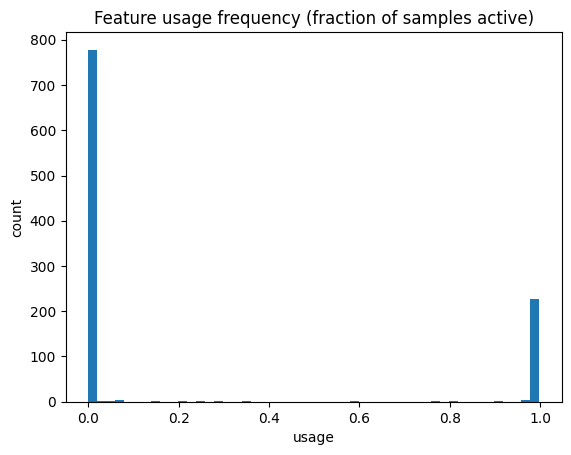

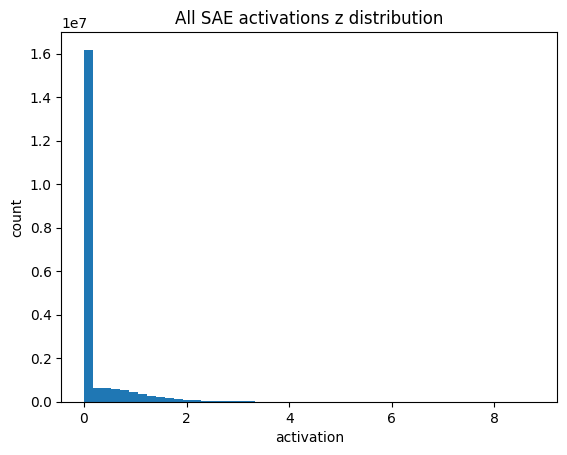

In [14]:
sae.eval()
with torch.no_grad():
    xhat, z = sae(X_train)
    recon_mse = F.mse_loss(xhat, X_train).item()

    var = X_train.var(dim=0, unbiased=False).mean().item()
    explained = 1.0 - recon_mse / (var + 1e-8)

    # Fraction of samples in which each feature is active (non-zero)
    usage = (z > 0).float().mean(dim=0)
    dead = int((usage == 0).sum().item())
    avg_active = (z > 0).float().sum(dim=1).float().mean().item()

print('recon_mse:', recon_mse)
print('explained_var:', explained)
print('dead_features:', dead, '/', d_dict)
print('avg_active_per_sample:', avg_active)

plt.figure()
plt.hist(usage.cpu().numpy(), bins=50)
plt.title('Feature usage frequency (fraction of samples active)')
plt.xlabel('usage')
plt.ylabel('count')
plt.show()

plt.figure()
plt.hist(z.cpu().numpy().ravel(), bins=50)
plt.title('All SAE activations z distribution')
plt.xlabel('activation')
plt.ylabel('count')
plt.show()


## 6. Visualize feature semantics: top-activating inputs
For a given feature id, we retrieve the top-k images that maximize the SAE activation for that feature.


Top-used feature ids: [758, 2, 266, 649, 34, 148, 513, 141, 602, 926]


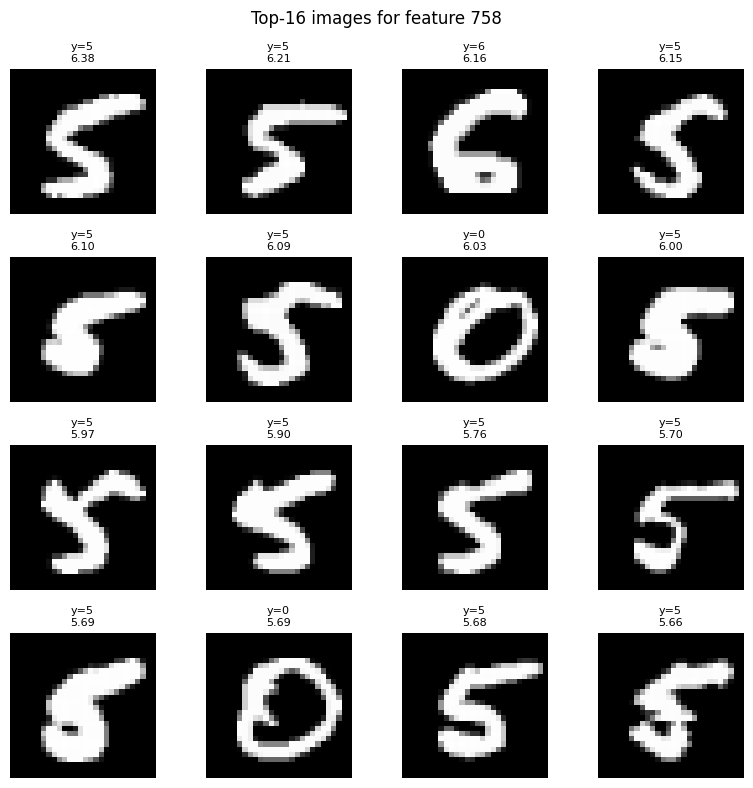

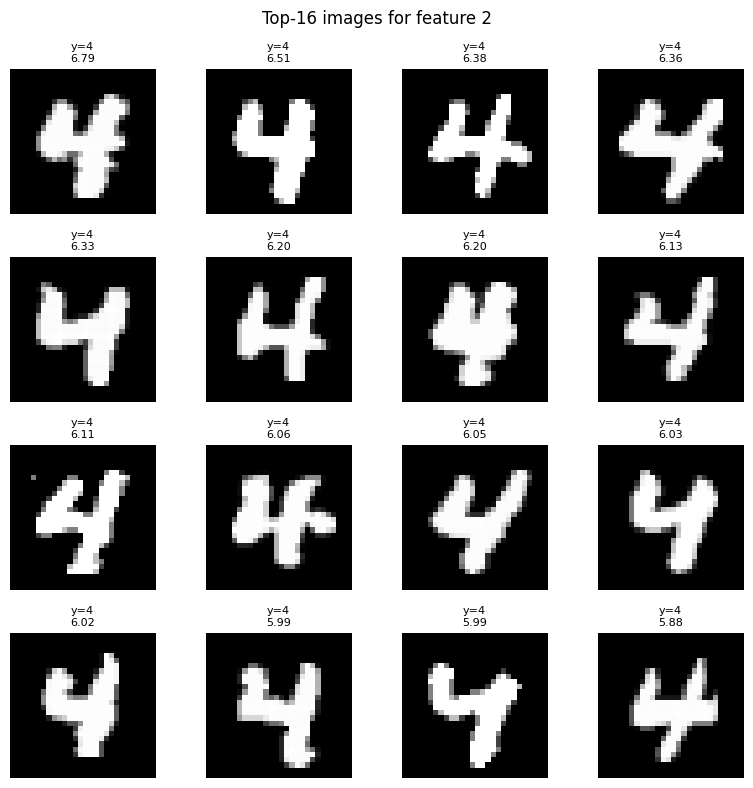

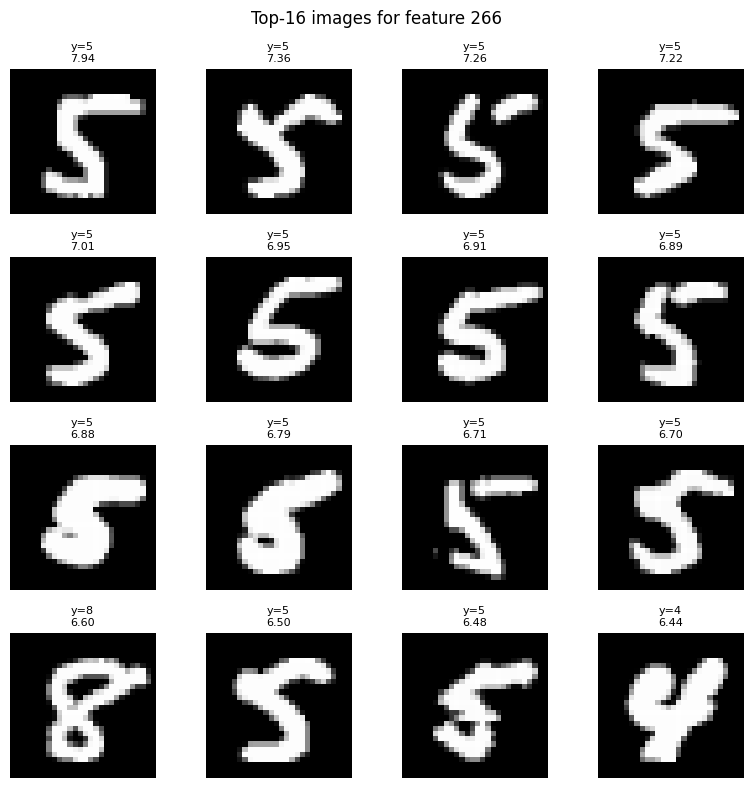

In [15]:
def show_topk(feature_id: int, k: int = 16):
    sae.eval()
    with torch.no_grad():
        # For this toy scale, compute z for the whole cache.
        # For larger datasets, do this in batches.
        _, z_all = sae(X_train)
        scores = z_all[:, feature_id].detach().cpu()
    top = torch.topk(scores, k=k).indices

    side = int(math.sqrt(k))
    if side * side != k:
        side = int(math.ceil(math.sqrt(k)))

    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(top):
        plt.subplot(side, side, i + 1)
        plt.imshow(IMG[idx][0], cmap='gray')
        plt.axis('off')
        plt.title(f'y={int(Y[idx])}\n{scores[idx]:.2f}', fontsize=8)
    plt.suptitle(f'Top-{k} images for feature {feature_id}')
    plt.tight_layout()
    plt.show()

# Pick a few nontrivial features by usage
top_used = torch.argsort(usage, descending=True)[:10]
print('Top-used feature ids:', top_used.tolist())

for fid in top_used.tolist()[:3]:
    show_topk(fid, k=16)


## 7. Optional: quick dead-feature check and a few random features
This helps show that some features may be dead or extremely rare depending on λ and training.


num dead: 761
first few dead feature ids: [0, 1, 4, 6, 7, 8, 9, 11, 12, 14]
random feature ids: [277, 11, 202]


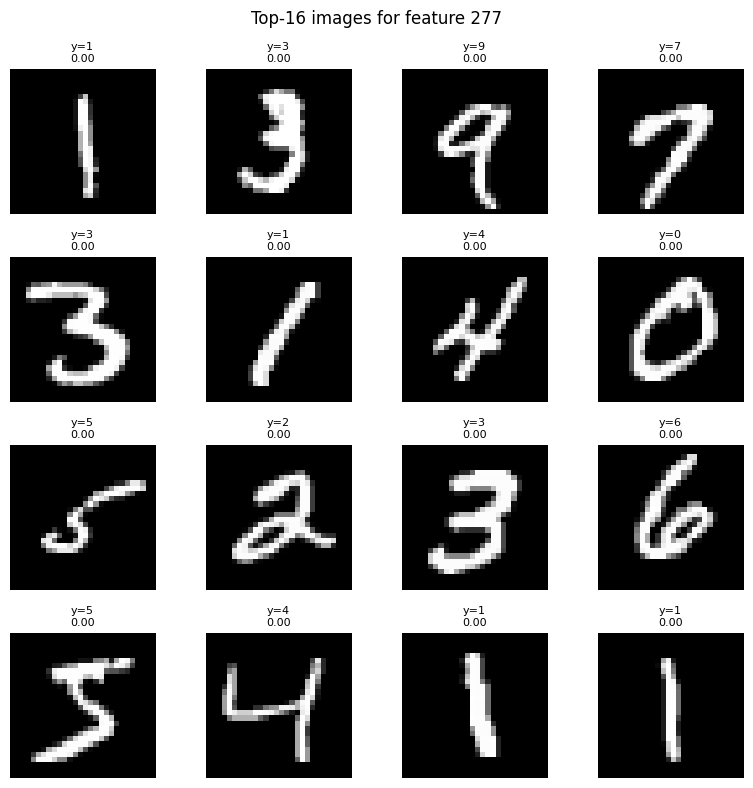

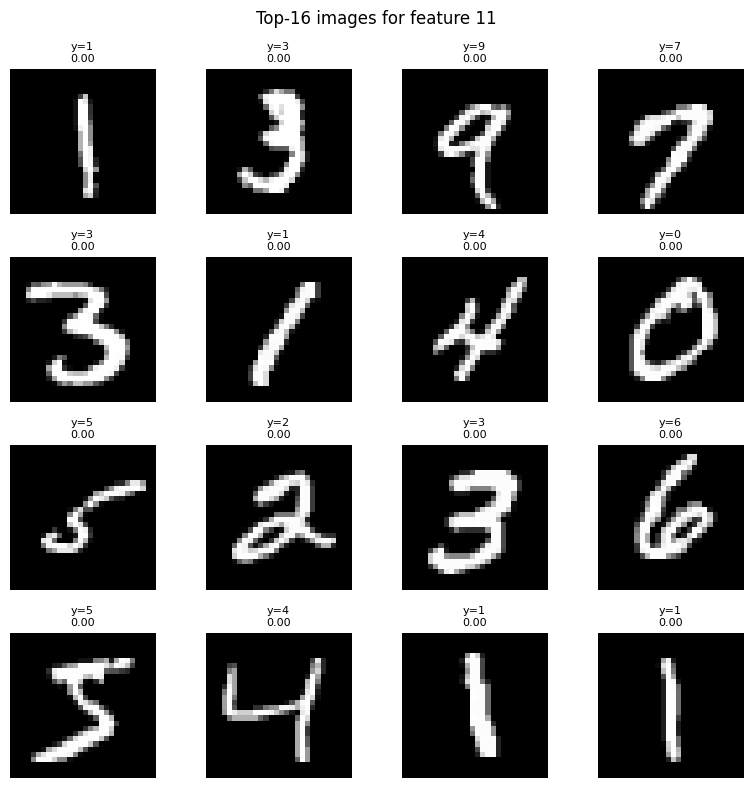

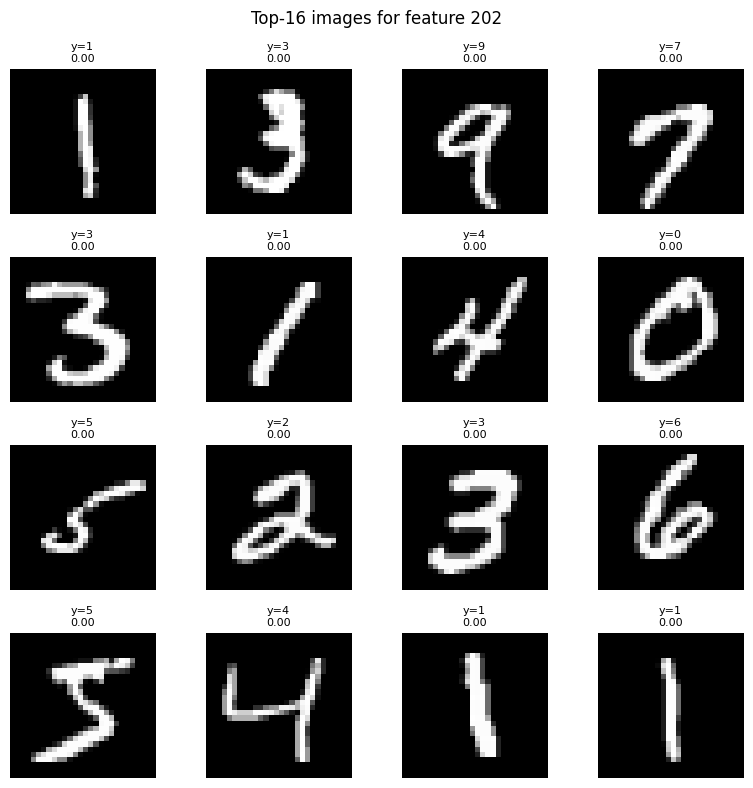

In [8]:
dead_ids = (usage == 0).nonzero(as_tuple=False).view(-1)
print('num dead:', dead_ids.numel())
if dead_ids.numel() > 0:
    print('first few dead feature ids:', dead_ids[:10].tolist())

rand_features = torch.randint(0, d_dict, (3,)).tolist()
print('random feature ids:', rand_features)
for fid in rand_features:
    show_topk(fid, k=16)
